# ClaimWise Insurance Prediction — 09. Model Comparison

## 1. Objective

Train **all five** ClaimWise regression models on exactly the same prepared data, evaluate every one
of them on the same 10,000 test rows, compare their metrics and select the best model.

Selection rule (from `Src/model_training_utils.py`): the best model is the one with the **lowest
RMSE**; MAE, MSE and then the highest R² act as deterministic tie-breakers. No model is preferred
by name.

This notebook reuses the existing training pipeline `Src/train_models.py`, so the comparison table
is always regenerated from models trained in this run — the numbers are never typed in by hand.

## 2. Import Libraries

In [1]:
%matplotlib inline

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image

In [2]:
from pathlib import Path
import sys


def find_project_root(start: Path) -> Path:
    """Walk upwards from the notebook folder until the ClaimWise project is found."""
    for candidate in [start, *start.parents]:
        if (candidate / "Dataset").is_dir() and (candidate / "Src").is_dir():
            return candidate
    raise FileNotFoundError(f"ClaimWise project root not found above: {start}")


PROJECT_ROOT = find_project_root(Path.cwd())
DATASET_DIR = PROJECT_ROOT / "Dataset"
SRC_DIR = PROJECT_ROOT / "Src"
MODELS_DIR = PROJECT_ROOT / "Models"
OUTPUTS_DIR = PROJECT_ROOT / "Outputs"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("Project root  :", PROJECT_ROOT)
print("Dataset folder:", DATASET_DIR)
print("Src folder    :", SRC_DIR)

from model_training_utils import (
    calculate_metrics,
    load_prepared_data,
    save_model_results,
)

Project root  : /Users/padaltiruvinayak/Desktop/Credit ML
Dataset folder: /Users/padaltiruvinayak/Desktop/Credit ML/Dataset
Src folder    : /Users/padaltiruvinayak/Desktop/Credit ML/Src


In [3]:
# Src/model_training_utils.py switches matplotlib to the non-interactive Agg backend so the
# command-line scripts can run without a display. Switch back to the inline backend here so
# that every figure below is rendered inside this notebook.
%matplotlib inline

## 3. Load Prepared Data

In [4]:
X_train, X_test, y_train, y_test = load_prepared_data()

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train:", y_train.shape, "| y_test:", y_test.shape)
print("Input features:", X_train.shape[1], "| target:", y_train.name)

X_train: (40000, 130) | X_test: (10000, 130)
y_train: (40000,) | y_test: (10000,)
Input features: 130 | target: loss


## 4. Train All Five Models

`train_models.py` trains Linear Regression, Decision Tree, Random Forest, Gradient Boosting and Hist
Gradient Boosting (the model adapted from the provided Google Drive code) with
their fixed hyperparameters (`random_state=42`), writes each model's `metrics.csv` and
`predictions.csv`, builds the ranked comparison table and copies the winning model to
`Models/best_model.pkl`.

In [5]:
from train_models import main as train_all_models

train_all_models()

Loaded prepared data: X_train=(40000, 130), X_test=(10000, 130)
Preprocessing is not repeated in this stage.

Training Linear Regression...


Linear Regression metrics: {'MAE': 1333.5664719302385, 'MSE': 4204641.706442131, 'RMSE': 2050.522300888759, 'R2': 0.4826150637154484}

Training Decision Tree Regressor...


Decision Tree Regressor metrics: {'MAE': 1609.9189008598992, 'MSE': 6964030.449791089, 'RMSE': 2638.944950125161, 'R2': 0.1430698018743468}

Training Random Forest Regressor...


Random Forest Regressor metrics: {'MAE': 1259.6218494618547, 'MSE': 3937886.6823712313, 'RMSE': 1984.4109157055227, 'R2': 0.5154395088806684}

Training Gradient Boosting Regressor...


Gradient Boosting Regressor metrics: {'MAE': 1277.782914322996, 'MSE': 4021053.5724743223, 'RMSE': 2005.256485458736, 'R2': 0.505205748398522}

Training Hist Gradient Boosting Regressor...


...

Fold 1/3: iterations=830 MAE=1215.3804 RMSE=1950.7341 R2=0.5618


Fold 2/3: iterations=572 MAE=1224.1672 RMSE=1913.9725 R2=0.5349


Fold 3/3: iterations=842 MAE=1204.9775 RMSE=2004.2711 R2=0.5473
OOF metrics: {'MAE': 1214.8417170260398, 'MSE': 3828585.111163176, 'RMSE': 1956.6770584752037, 'R2': 0.5484235111544639}
Best iterations per fold: [830, 572, 842]

Fitting final model on all 40000 training rows (max_iter=830, median best fold iteration)...


Hist Gradient Boosting Regressor metrics: {'MAE': 1215.299702959891, 'MSE': 3690333.1164736343, 'RMSE': 1921.0239760277939, 'R2': 0.5459011973814277}
Cross-validation fold metrics:
   fold  iterations          MAE           MSE         RMSE        R2
0     1         830  1215.380389  3.805364e+06  1950.734097  0.561836
1     2         572  1224.167246  3.663291e+06  1913.972497  0.534920
2     3         842  1204.977475  4.017103e+06  2004.271149  0.547253



CLAIMWISE REGRESSION MODEL TRAINING COMPLETED
Linear Regression: MAE=1333.5665, MSE=4204641.7064, RMSE=2050.5223, R2=0.4826
Decision Tree Regressor: MAE=1609.9189, MSE=6964030.4498, RMSE=2638.9450, R2=0.1431
Random Forest Regressor: MAE=1259.6218, MSE=3937886.6824, RMSE=1984.4109, R2=0.5154
Gradient Boosting Regressor: MAE=1277.7829, MSE=4021053.5725, RMSE=2005.2565, R2=0.5052
Hist Gradient Boosting Regressor: MAE=1215.2997, MSE=3690333.1165, RMSE=1921.0240, R2=0.5459

Best model: Hist Gradient Boosting Regressor
Best model metrics: {'MAE': 1215.299702959891, 'MSE': 3690333.1164736343, 'RMSE': 1921.023976027794, 'R2': 0.5459011973814277}
Saved best model to: /Users/padaltiruvinayak/Desktop/Credit ML/Models/best_model.pkl


## 5. Comparison Table

Read back from `Outputs/Model_Comparison/model_comparison.csv`, which was written during this run.

In [6]:
comparison_path = OUTPUTS_DIR / "Model_Comparison" / "model_comparison.csv"

if not comparison_path.exists():
    raise FileNotFoundError(f"Comparison file was not created: {comparison_path}")

comparison = pd.read_csv(comparison_path)
display(comparison)

print("Ranking rule: lowest RMSE first (then MAE, MSE, then highest R2).")
best_name = str(comparison.iloc[0]["Model"])
print("Best model according to the actual test metrics:", best_name)

,Model,MAE,MSE,RMSE,R2
0,Hist Gradient Boosting Regressor,1215.299703,3.690333e+06,1921.023976,0.545901
1,Random Forest Regressor,1259.621849,3.937887e+06,1984.410916,0.515440
2,Gradient Boosting Regressor,1277.782914,4.021054e+06,2005.256485,0.505206
3,Linear Regression,1333.566472,4.204642e+06,2050.522301,0.482615
4,Decision Tree Regressor,1609.918901,6.964030e+06,2638.944950,0.143070


Ranking rule: lowest RMSE first (then MAE, MSE, then highest R2).
Best model according to the actual test metrics: Hist Gradient Boosting Regressor


## 6. Comparison Visualization

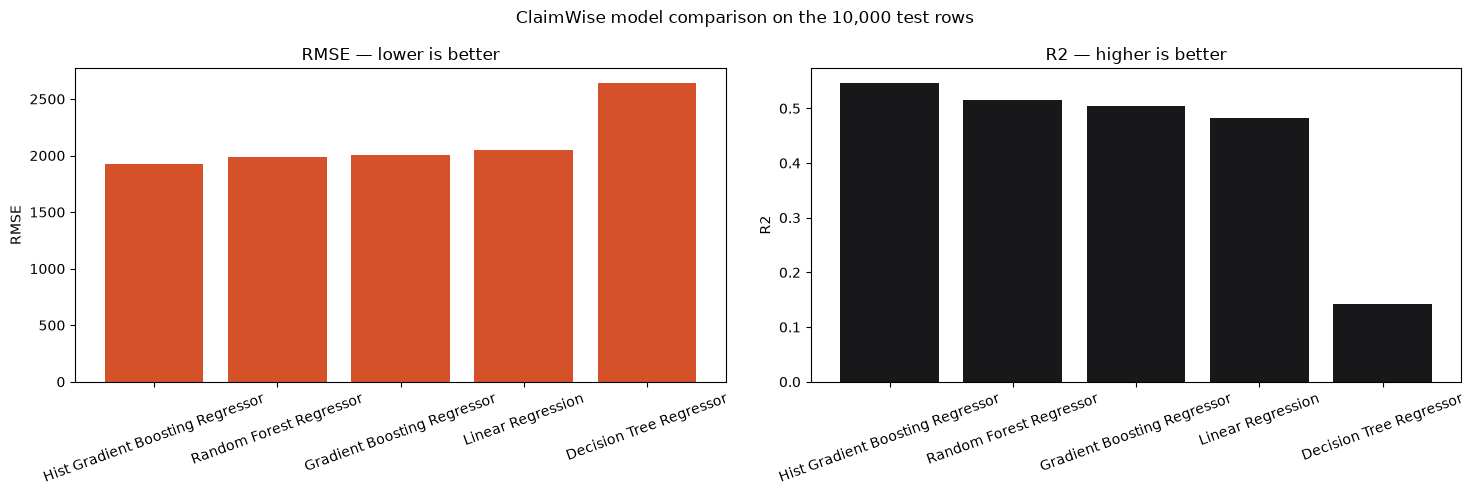

Saved: /Users/padaltiruvinayak/Desktop/Credit ML/Outputs/Model_Comparison/model_comparison_bar_chart.png


In [7]:
comparison_dir = OUTPUTS_DIR / "Model_Comparison"
comparison_dir.mkdir(parents=True, exist_ok=True)

ordered = comparison.sort_values("RMSE", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(ordered["Model"], ordered["RMSE"], color="#D4512A")
axes[0].set_title("RMSE — lower is better")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(ordered["Model"], ordered["R2"], color="#18181B")
axes[1].set_title("R2 — higher is better")
axes[1].set_ylabel("R2")
axes[1].tick_params(axis="x", rotation=20)

fig.suptitle("ClaimWise model comparison on the 10,000 test rows")
fig.tight_layout()
bar_path = comparison_dir / "model_comparison_bar_chart.png"
fig.savefig(bar_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", bar_path)

## 7. Verify the Saved Best Model

In [8]:
expected_class = {
    "Linear Regression": "LinearRegression",
    "Decision Tree Regressor": "DecisionTreeRegressor",
    "Random Forest Regressor": "RandomForestRegressor",
    "Gradient Boosting Regressor": "GradientBoostingRegressor",
    "Hist Gradient Boosting Regressor": "HistGradientBoostingRegressor",
}

best_model_path = MODELS_DIR / "best_model.pkl"
if not best_model_path.exists():
    raise FileNotFoundError(f"Best model artifact missing: {best_model_path}")

best_model = joblib.load(best_model_path)
loaded_class = type(best_model).__name__

print("Best model according to the metrics :", best_name)
print("Class inside Models/best_model.pkl  :", loaded_class)
assert loaded_class == expected_class[best_name], (
    f"best_model.pkl holds {loaded_class} but the metrics say {best_name}"
)
print("Verified: the saved best model matches the lowest-RMSE model of this run.")

y_pred_best = best_model.predict(X_test)
best_metrics = calculate_metrics(y_test, y_pred_best)
print("Metrics recomputed from the saved artifact:", best_metrics)

Best model according to the metrics : Hist Gradient Boosting Regressor
Class inside Models/best_model.pkl  : HistGradientBoostingRegressor
Verified: the saved best model matches the lowest-RMSE model of this run.
Metrics recomputed from the saved artifact: {'MAE': 1215.299702959891, 'MSE': 3690333.1164736343, 'RMSE': 1921.0239760277939, 'R2': 0.5459011973814277}


## 8. Best Model Figures

Actual vs predicted and residual plots for the winning model, saved by the training pipeline.

actual_vs_predicted.png


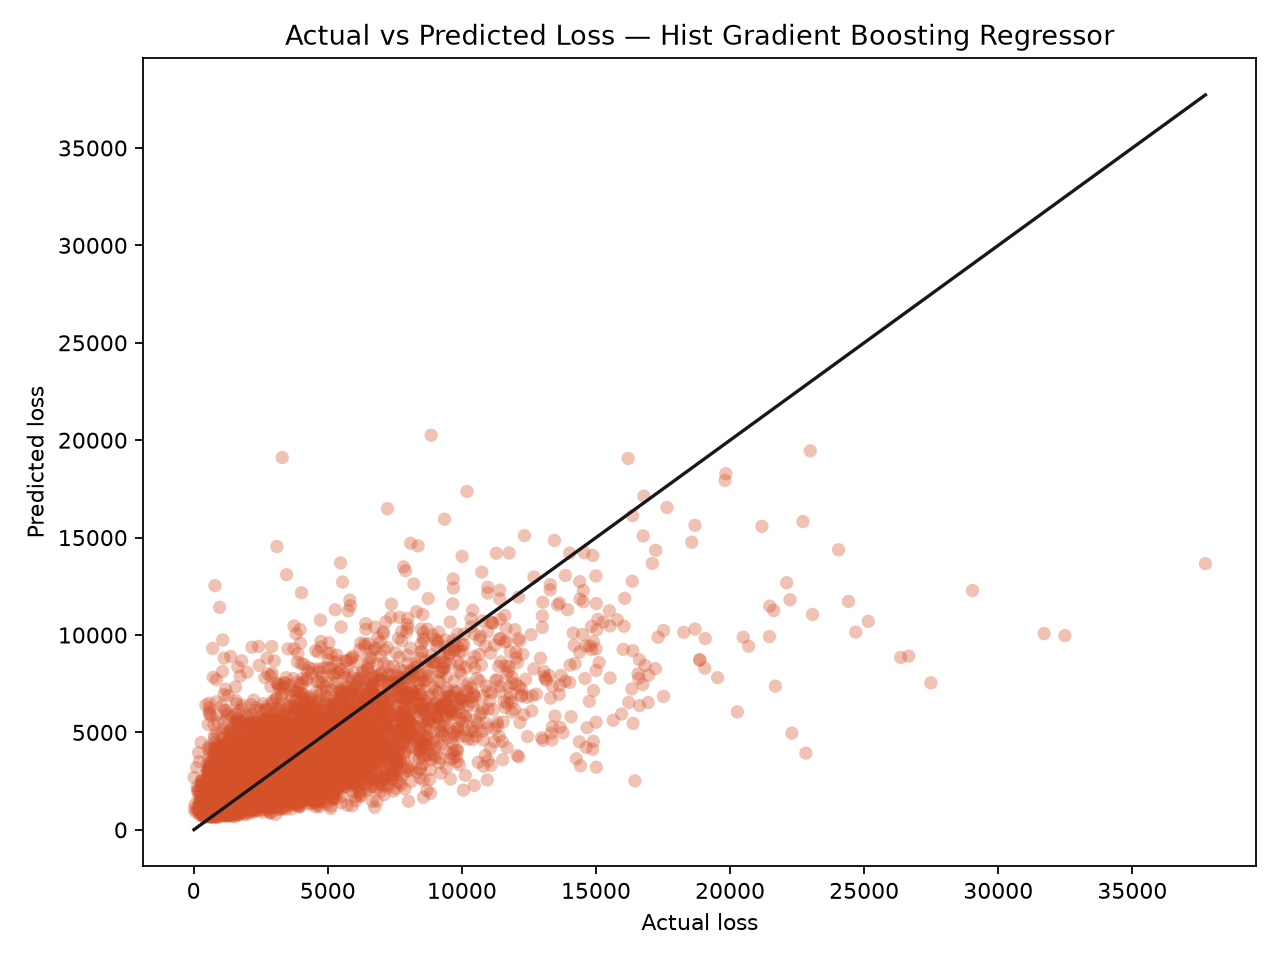

residuals.png


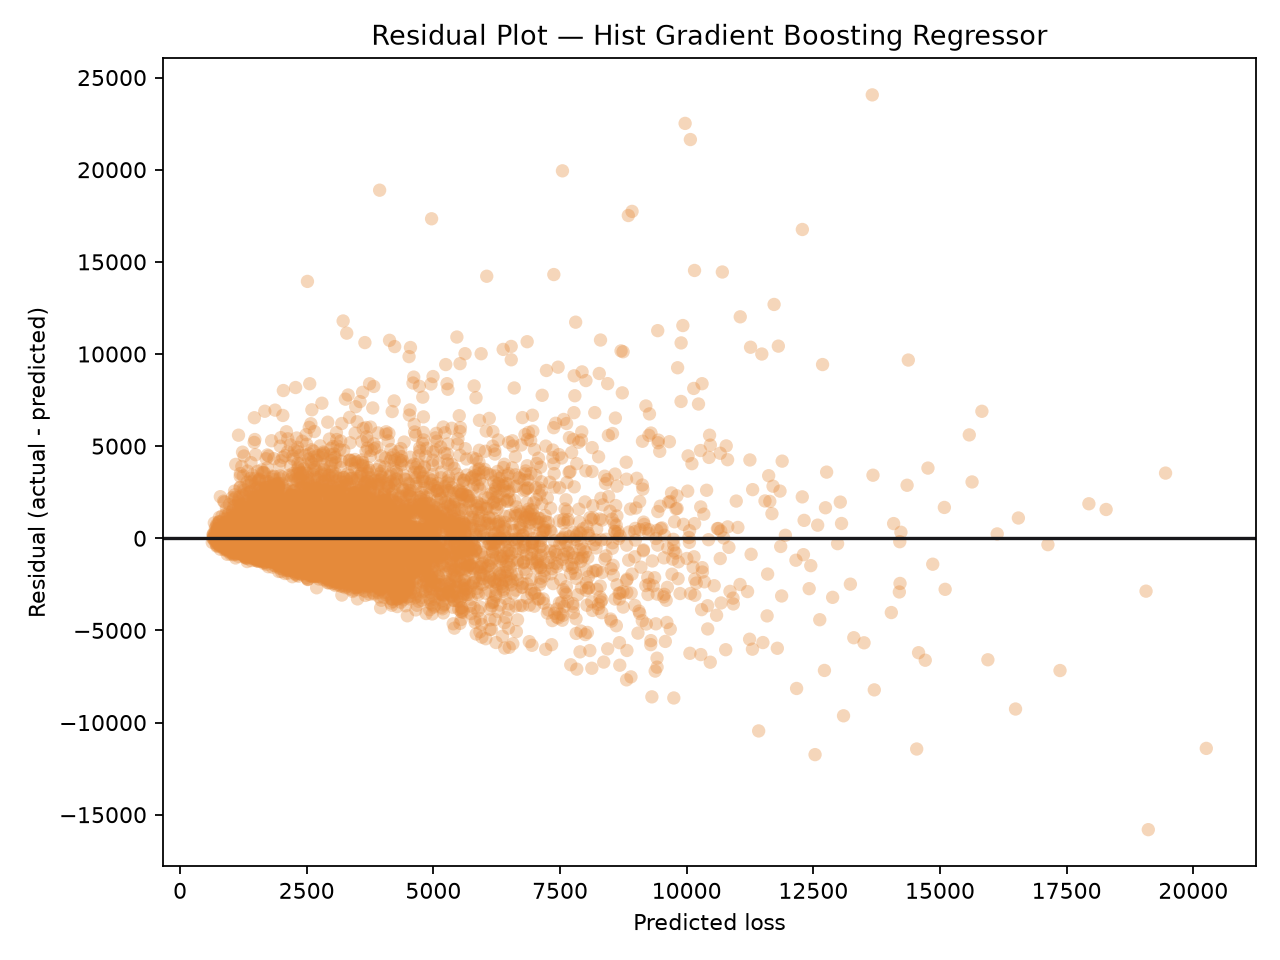

In [9]:
for figure_name in ["actual_vs_predicted.png", "residuals.png"]:
    print(figure_name)
    display(Image(filename=str(comparison_dir / figure_name)))

## 9. Conclusion

All five models were trained in this run on identical data and compared on the same 10,000 test
rows. Actual results:

| Rank | Model | MAE | MSE | RMSE | R² |
|---:|---|---:|---:|---:|---:|
| 1 | Hist Gradient Boosting Regressor | 1215.2997 | 3690333.1165 | 1921.0240 | 0.545901 |
| 2 | Random Forest Regressor | 1259.6218 | 3937886.6824 | 1984.4109 | 0.515440 |
| 3 | Gradient Boosting Regressor | 1277.7829 | 4021053.5725 | 2005.2565 | 0.505206 |
| 4 | Linear Regression | 1333.5665 | 4204641.7064 | 2050.5223 | 0.482615 |
| 5 | Decision Tree Regressor | 1609.9189 | 6964030.4498 | 2638.9450 | 0.143070 |

**Best model: Hist Gradient Boosting Regressor** — lowest RMSE (1921.0240) and highest R² (0.545901).
It was copied to `Models/best_model.pkl`, and the notebook verified that the class stored in that file
is indeed `HistGradientBoostingRegressor`.

Saved by this run: `Outputs/Model_Comparison/model_comparison.csv`,
`Outputs/Model_Comparison/model_comparison_bar_chart.png`, `actual_vs_predicted.png`, `residuals.png`.

Next: `10_ClaimWise_Final_Prediction.ipynb`.